<a href="https://colab.research.google.com/github/kerondavid-debug/Project-1-CNN/blob/main/Model_5Project_1_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets  import cifar10
from tensorflow.keras.utils import to_categorical

# Load cifar10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [38]:
# Normalize the images
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

In [39]:
from sklearn.model_selection import train_test_split

# Temporary holder for the 30% remaining data after the first split
x_train_sub, x_temp, y_train_sub, y_temp = train_test_split(
    x_train_normalized, y_train,
    test_size=0.3,
    stratify=y_train,
    random_state=42)

# Splitting the temporary holder into 15% validation data and 15% test data
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, # Use x_temp directly, as it is already normalized
    test_size=0.5,
    stratify=y_temp,
    random_state=42)

In [40]:
# Encoding the dataset
y_train_encoded = to_categorical(y_train_sub, num_classes=10)
y_val_encoded = to_categorical(y_val, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

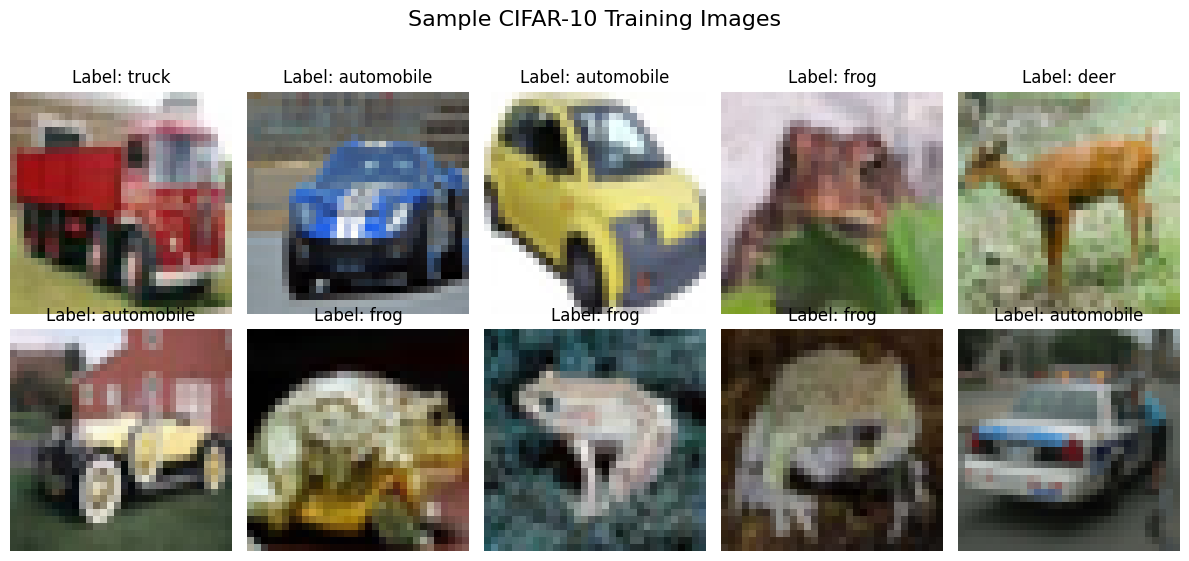

In [41]:
# Visualization
# Define the class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Get 10 random indices to display images
num_images_to_display = 10
random_indices = np.random.choice(x_train_sub.shape[0], num_images_to_display, replace=False)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1) # Arrange in 2 rows, 5 columns
    plt.imshow(x_train_sub[idx]) # Display the normalized image
    plt.title(f"Label: {class_names[np.argmax(y_train_encoded[idx])]}") # Get original label
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Training Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_2154/568526296.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=np.argmax(y_train_encoded, axis=1), ax=axes[0], palette='viridis')
/tmp/ipykernel_2154/568526296.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(class_names, rotation=45, ha='right')
/tmp/ipykernel_2154/568526296.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=np.argmax(y_val_encoded, axis=1), ax=axes[1], palette='viridis')
/tmp/ipykernel_2154/568526296.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

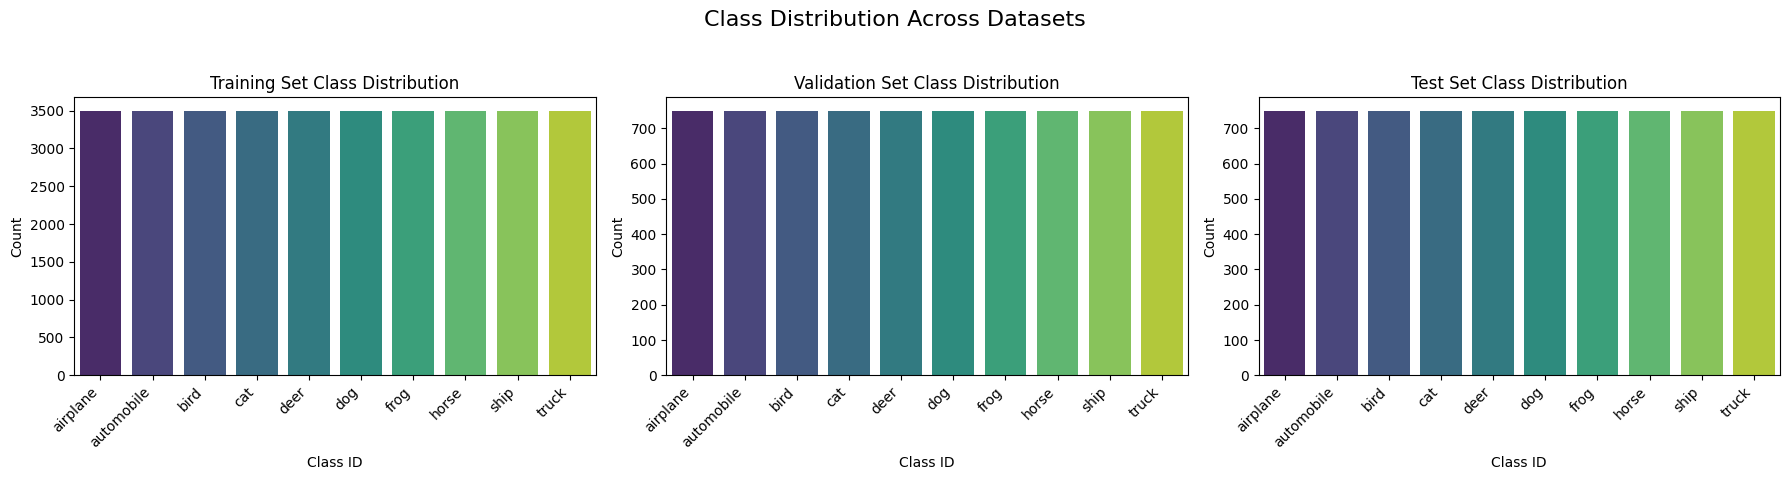

In [42]:
# Class Distributiion in training, validating and test sets using barcharts after using stratify.
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Class Distribution Across Datasets', fontsize=16)

# Training set distribution
sns.countplot(x=np.argmax(y_train_encoded, axis=1), ax=axes[0], palette='viridis')
axes[0].set_title('Training Set Class Distribution')
axes[0].set_xlabel('Class ID')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(class_names, rotation=45, ha='right')

# Validation set distribution
sns.countplot(x=np.argmax(y_val_encoded, axis=1), ax=axes[1], palette='viridis')
axes[1].set_title('Validation Set Class Distribution')
axes[1].set_xlabel('Class ID')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(class_names, rotation=45, ha='right')

# Test set distribution
sns.countplot(x=np.argmax(y_test_encoded, axis=1), ax=axes[2], palette='viridis')
axes[2].set_title('Test Set Class Distribution')
axes[2].set_xlabel('Class ID')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(class_names, rotation=45, ha='right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Convolutional Neural Network (CNN) Architecture Design

Now, let's define the CNN model using `tf.keras.models.Sequential`. The architecture will include:

*   **Convolutional Layers (`Conv2D`)**: To extract features from the input images.
*   **Activation Functions (`ReLU`)**: To introduce non-linearity.
*   **Max Pooling Layers (`MaxPooling2D`)**: To reduce spatial dimensions and make the model more robust to variations.
*   **Dropout Layers (`Dropout`)**: To prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time.
*   **Flatten Layer (`Flatten`)**: To convert the 2D feature maps into a 1D vector for the fully connected layers.
*   **Dense Layers (`Dense`)**: Fully connected layers for classification.

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, InputLayer, BatchNormalization

# Define the input shape (height, width, channels) for CIFAR-10 images
input_shape = x_train_sub.shape[1:] # (32, 32, 3)
num_classes = 10

model = Sequential([
    InputLayer(shape=input_shape),


    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten and Dense Layers
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Output layer for 10 classes
])

# Display the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,708,074 (6.52 MB)

 Trainable params: 1,705,130 (6.50 MB)

 Non-trainable params: 2,944 (11.50 KB)

### Current Model Configuration: With Batch Normalization and Dropout

The current model architecture now includes `BatchNormalization` layers after each `Conv2D` layer, in addition to the `Dropout` layers. This combination is typically used to improve training stability and reduce overfitting.

To evaluate the impact of these changes, the model needs to be re-compiled and re-trained.

In [44]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping

# Compile the model
model.compile(optimizer=SGD(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [45]:
# Define Callbacks
# Early Stopping: Monitor validation loss and stop if it doesn't improve for 10 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True);

# Train the model
history = model.fit(x_train_sub, y_train_encoded,
                    epochs=20,
                    batch_size=64,
                    validation_data=(x_val, y_val_encoded),
                    callbacks=[early_stopping])

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.3030 - loss: 2.2303 - val_accuracy: 0.3771 - val_loss: 1.7225
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.4301 - loss: 1.6033 - val_accuracy: 0.5192 - val_loss: 1.3536
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.4957 - loss: 1.3936 - val_accuracy: 0.5169 - val_loss: 1.3233
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5465 - loss: 1.2590 - val_accuracy: 0.6004 - val_loss: 1.0924
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5811 - loss: 1.1583 - val_accuracy: 0.6231 - val_loss: 1.0506
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6125 - loss: 1.0855 - val_accuracy: 0.6172 - val_loss: 1.0637
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6343 - loss: 1.0220 - val_accuracy: 0.6347 - val_loss: 1.0221
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6556 - loss: 0.9688 - val_acc

In [53]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [54]:
import pandas as pd

# Convert the history.history dict to a pandas DataFrame for a clean tabular format
history_df = pd.DataFrame(history.history)
display(history_df.head())

# You can also get a summary of the best epoch based on validation loss
best_epoch = history_df['val_loss'].idxmin()
print(f"Best epoch based on validation loss: {best_epoch + 1}")
print(f"Validation Loss at best epoch: {history_df.loc[best_epoch, 'val_loss']:.4f}")
print(f"Validation Accuracy at best epoch: {history_df.loc[best_epoch, 'val_accuracy']:.4f}")

,accuracy,loss,val_accuracy,val_loss
0,0.303029,2.230320,0.377067,1.722504
1,0.430143,1.603320,0.519200,1.353570
2,0.495714,1.393613,0.516933,1.323307
3,0.546543,1.258998,0.600400,1.092408
4,0.581143,1.158265,0.623067,1.050559


Best epoch based on validation loss: 20
Validation Loss at best epoch: 0.6213
Validation Accuracy at best epoch: 0.7860


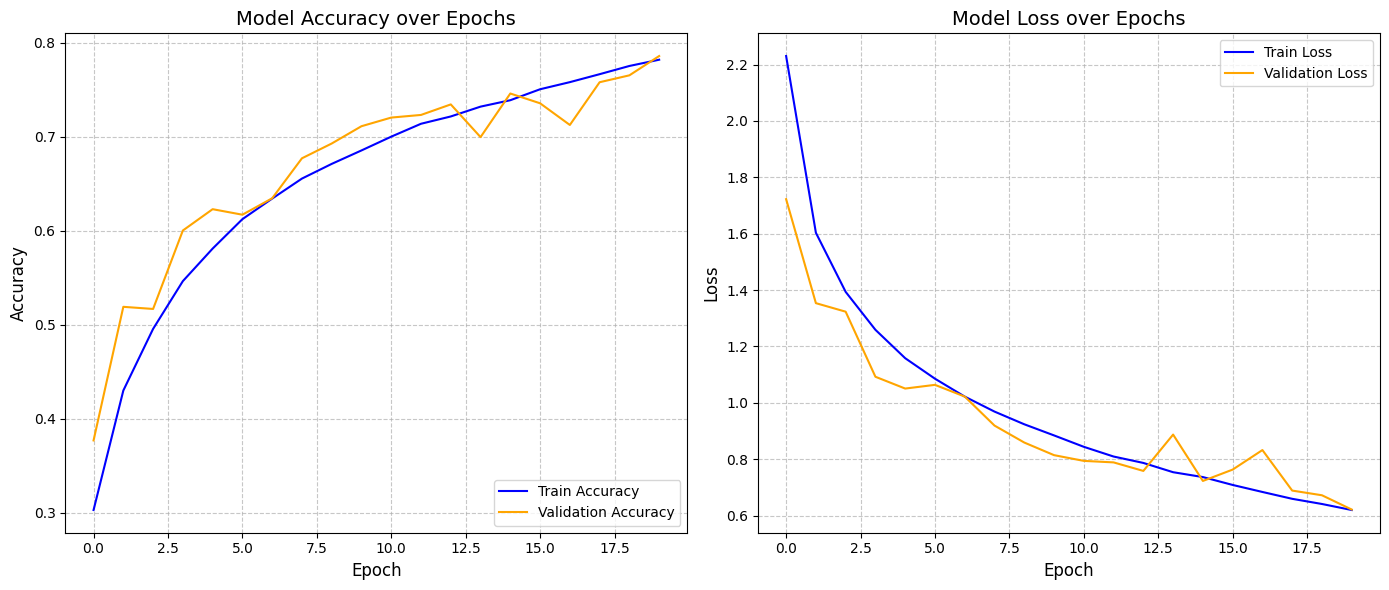

In [55]:
import matplotlib.pyplot as plt

# Create a figure with two subplots for accuracy and loss
plt.figure(figsize=(14, 6))

# Subplot 1: Training and Validation Accuracy
plt.subplot(1, 2, 1) # (rows, columns, panel number)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy over Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss over Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [56]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import numpy as np

# Make predictions on the test set
y_pred_encoded = model.predict(x_test)
y_pred = np.argmax(y_pred_encoded, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

# Calculate overall accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Calculate precision, recall, f1-score for each class
precision, recall, f1_score, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=np.arange(len(class_names)))

print("\nClass-wise Metrics:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name:<10}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1-score={f1_score[i]:.4f}")

# Calculate macro-averaged metrics
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
print(f"\nMacro-averaged Precision: {precision_macro:.4f}")
print(f"Macro-averaged Recall: {recall_macro:.4f}")
print(f"Macro-averaged F1-score: {f1_score_macro:.4f}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Test Accuracy: 0.7788

Class-wise Metrics:
  airplane  : Precision=0.8905, Recall=0.7587, F1-score=0.8193
  automobile: Precision=0.8999, Recall=0.8627, F1-score=0.8809
  bird      : Precision=0.7804, Recall=0.6253, F1-score=0.6943
  cat       : Precision=0.6020, Recall=0.5707, F1-score=0.5859
  deer      : Precision=0.7401, Recall=0.7707, F1-score=0.7551
  dog       : Precision=0.6092, Recall=0.7773, F1-score=0.6831
  frog      : Precision=0.7506, Recall=0.8667, F1-score=0.8045
  horse     : Precision=0.8161, Recall=0.7987, F1-score=0.8073
  ship      : Precision=0.9029, Recall=0.8800, F1-score=0.8913
  truck     : Precision=0.8647, Recall=0.8773, F1-score=0.8709

Macro-averaged Precision: 0.7856
Macro-averaged Recall: 0.7788
Macro-averaged F1-score: 0.7792


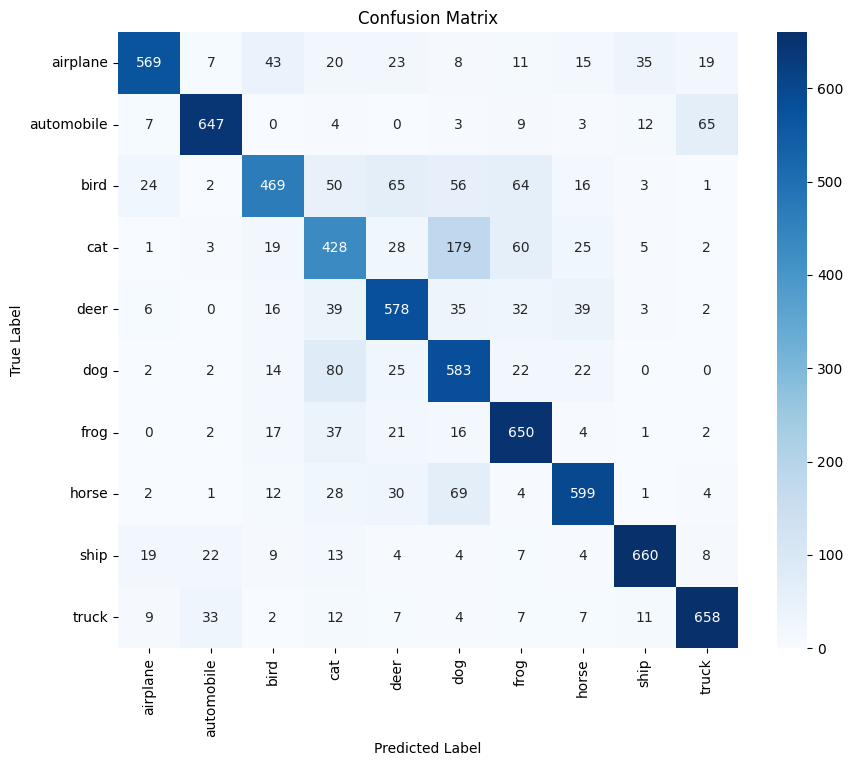

In [57]:
# Visualize the confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [58]:
print(f"Best epoch based on validation loss: {best_epoch + 1}")

current_model_training_accuracy = history_df.loc[best_epoch, 'accuracy']
current_model_validation_accuracy = history_df.loc[best_epoch, 'val_accuracy']
current_model_validation_loss = history_df.loc[best_epoch, 'val_loss']

print(f"\nModel Metrics (at best epoch {best_epoch + 1}):")
print(f"  Training Accuracy: {current_model_training_accuracy:.4f}")
print(f"  Validation Accuracy: {current_model_validation_accuracy:.4f}")
print(f"  Validation Loss: {current_model_validation_loss:.4f}")
print(f"  Test Accuracy: {accuracy:.4f}")

Best epoch based on validation loss: 20

Model Metrics (at best epoch 20):
  Training Accuracy: 0.7821
  Validation Accuracy: 0.7860
  Validation Loss: 0.6213
  Test Accuracy: 0.7788


In [59]:
model.save("Base-Model.keras")
from google.colab import drive
drive.mount('/content/drive')
model.save('/content/drive/MyDrive/Base-Model.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
